In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt
data_path = "../../data/project_7/"

In [2]:
df_1e3 = pd.read_csv(f"{data_path}run_values_N_1000.csv")
df_1e4 = pd.read_csv(f"{data_path}run_values_N_10000.csv")
#df_1e5 = pd.read_csv(f"{data_path}mu_values_N_100000.csv")

In [3]:
df_1e3.tail()

,T_values,mu_mean,mu_std,gcc_mean,gcc_std
45,7.485714,-4.525967,0.015269,0.061600,0.019431
46,8.114286,-4.961911,0.017191,0.066375,0.022546
47,8.742857,-5.392265,0.012891,0.062275,0.016215
48,9.371429,-5.829820,0.014756,0.059088,0.016244
49,10.000000,-6.262844,0.015254,0.063387,0.018792


In [22]:
plt.rcParams.update({
    # Font
    "font.weight": "bold",
    "font.size":25,

    # Axes
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 30,
    "axes.labelsize": 30,

    # Tick labels
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,

    # Legend
    "legend.fontsize": 25,
    "legend.title_fontsize": 20,

    # Figure title
    "figure.titleweight": "bold",
    "figure.titlesize": 20,

    # Math text (matches regular font)
    "mathtext.default": "bf",
})

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_670101/3128259034.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$|\mu|$", fontweight="bold")


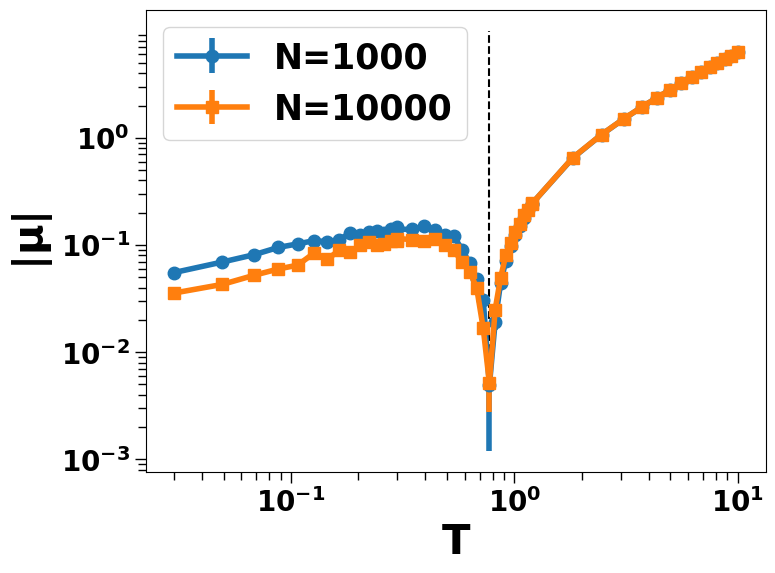

In [33]:
temp = df_1e3["T_values"]

fig, ax = plt.subplots(figsize=(8, 6))

    
y = np.abs(df_1e3["mu_mean"])
ax.errorbar(temp, np.abs(df_1e3["mu_mean"]), yerr=np.abs(df_1e3["mu_std"]/sqrt(80)), marker="o", markersize=9, linewidth=4)
ax.errorbar(temp, np.abs(df_1e4["mu_mean"]), yerr=np.abs(df_1e4["mu_std"]/sqrt(50)), marker="s", markersize=9, linewidth=4)

Tc = temp[y.argmin()]
ax.vlines(Tc, 1e-2, 1e1,  color="black", linestyles="dashed", label='_nolegend_')

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("T", fontweight="bold")
ax.set_ylabel("$|\mu|$", fontweight="bold")
ax.set_xticks([1e-1, 1e0, 1e1])
ax.set_yticks([1e-3, 1e-2, 1e-1, 1e0])
ax.tick_params(axis='both', which='minor', labelsize=20, length=6, width=1)
ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1)
#ax.set_yticklabels(ax.get_yticks(), fontweight="bold")

ax.legend([ "N=1000", "N=10000"])

plt.savefig("../../latex/images/mu.png", dpi=300,bbox_inches="tight")

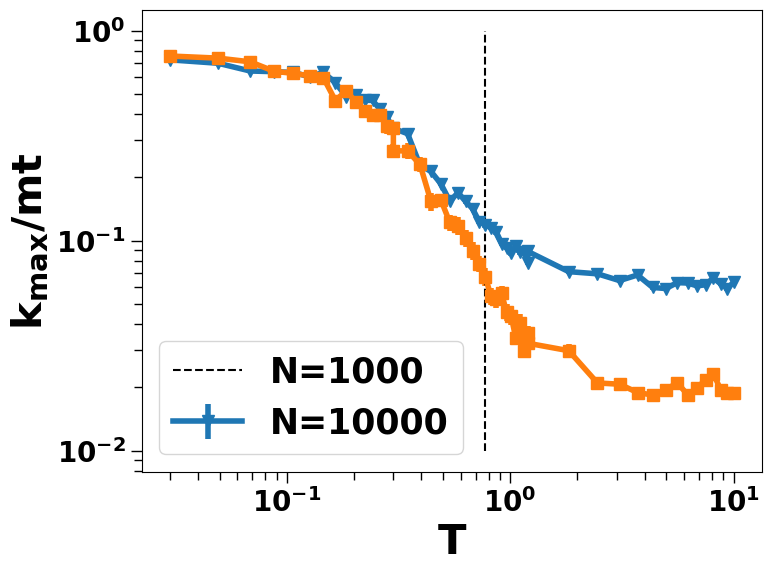

In [38]:
temp = df_1e3["T_values"]

fig, ax = plt.subplots(figsize=(8, 6))

    
y = np.abs(df_1e3["mu_mean"])
ax.errorbar(temp, df_1e3["gcc_mean"] , yerr=np.abs(df_1e3["mu_std"]/sqrt(80)), marker="v", markersize=9, linewidth=4)
ax.errorbar(temp, df_1e4["gcc_mean"] , yerr=np.abs(df_1e4["gcc_std"]/sqrt(50)), marker="s", markersize=9, linewidth=4)

ax.vlines(Tc, 1e-2, 1e0,  color="black", linestyles="dashed", label='no_legend')

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("T", fontweight="bold")
ax.set_ylabel("$k_{max} / mt$", fontweight="bold")
ax.set_xticks([1e-1, 1e0, 1e1])
ax.set_yticks([1e-2, 1e-1, 1e0])
ax.tick_params(axis='both', which='minor', labelsize=20, length=6, width=1)
ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1)
#ax.set_yticklabels(ax.get_yticks(), fontweight="bold")

ax.legend(["N=1000", "N=10000"], loc="lower left")

plt.savefig("../../latex/images/gcc.png", dpi=300, bbox_inches="tight")